# 🦷 AI Dental Image Screening — Project Progress Log
**Author:** Ayomide Zaccheaus | **Intern ID:** DF2025-074
**Date Started:** February 2026 | **Internship:** Dataraflow

---

## 1. Project Overview
This project builds an AI-powered dental image screening prototype that uses machine learning and computer vision to classify oral health conditions from patient-uploaded images. The goal is a beginner-friendly, reproducible pipeline demonstrating early detection of conditions like cavities, oral lesions, and gum disease.

---

## 2. Literature Review & Reference Implementation
Before writing any code, a literature review was conducted to identify the most current research and a suitable open-source implementation to build upon.

**Key papers reviewed (2024–2025):**
- *Advanced Deep Learning Techniques for Classifying Dental Conditions Using Panoramic X-Ray Images* (2025)
- *A Comprehensive Deep Learning Framework for Dental Disease Classification* (2025)
- *Deep Learning Applications in Dental Image-Based Diagnostics: A Systematic Review* (2025)

**Reference GitHub repository:**
https://github.com/summerchu24/Dental-Imaging-Modeling-AI

---

## 3. Dataset Acquisition
- **Platform:** Google Colab
- **Data source:** Kaggle API (authenticated via kaggle.json)

### Dataset 1 — Dental Segmentation (Primary)
**Name:** DentalAI-2
**Source:** kaggle.com/datasets/pawanvalluri/dental-segmentation
**License:** CC BY 4.0
**Type:** Image + Mask pairs (Semantic Segmentation)
**Total Images:** 2,495
**Split:** Train: 3,983 / Test: 501 / Valid: 509

**Classes:**
- 0 → Background
- 1 → Caries
- 2 → Cavity
- 3 → Crack
- 4 → Tooth

### Dataset 2 — Oral Lesions (Secondary)
**Name:** Oral Lesions Dataset
**Source:** kaggle.com/datasets/srprojects/oral-lesions
**Type:** Multi-class image classification
**Total Images:** 261
**Classes:** Other Oral White Lesions (92), Oral Non-Homogenous Leukoplakia (77), Oral Homogenous Leukoplakia (92)

---



In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayomidezaccheaus","key":"cc0ce927ead9cca408ff00e38487c5b4"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle API ready!")

Kaggle API ready!


In [ ]:
!pip install kaggle

!kaggle datasets download -d pawanvalluri/dental-segmentation --unzip -p /content/data/dental

!kaggle datasets download -d srprojects/oral-lesions --unzip -p /content/data/oral-lesions

Dataset URL: https://www.kaggle.com/datasets/pawanvalluri/dental-segmentation
License(s): unknown
 96% 975M/0.99G [00:11<00:00, 222MB/s]
100% 0.99G/0.99G [00:11<00:00, 92.4MB/s]
Dataset URL: https://www.kaggle.com/datasets/srprojects/oral-lesions
License(s): unknown
  0% 0.00/20.5M [00:00<?, ?B/s]
100% 20.5M/20.5M [00:00<00:00, 1.08GB/s]


In [ ]:
import os
for folder in ['/content/data/dental', '/content/data/oral-lesions']:
    print(f"\n📁 {folder}")
    for item in os.listdir(folder):
        print(f"   └── {item}")


📁 /content/data/dental
   └── dentalai-2

📁 /content/data/oral-lesions
   └── Dataset


In [ ]:
import os

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 3:  # only go 3 levels deep
        for f in files[:5]:  # show first 5 files only
            print(f"{indent}   └── {f}")

📁 data/
   📁 oral-lesions/
      📁 Dataset/
         📁 Oral Homogenous Leukoplakia/
         📁 Other Oral White Lesions/
         📁 Oral Non Homogenous Leukoplakia/
   📁 dental/
      📁 dentalai-2/
         └── README.roboflow.txt
         └── README.dataset.txt
         📁 train/
         📁 valid/
         📁 test/


In [ ]:
# Dental dataset structure
import os
dental_path = '/content/data/dental/dentalai-2'
for root, dirs, files in os.walk(dental_path):
    level = root.replace(dental_path, '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(root)}/ → {len(files)} images")

📁 dentalai-2/ → 2 images
   📁 train/ → 3983 images
   📁 valid/ → 509 images
   📁 test/ → 501 images


In [ ]:
# Oral lesions full structure
import os
oral_path = '/content/data/oral-lesions/Dataset'
for root, dirs, files in os.walk(oral_path):
    level = root.replace(oral_path, '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(root)}/ → {len(files)} images")

📁 Dataset/ → 0 images
   📁 Oral Homogenous Leukoplakia/ → 92 images
   📁 Other Oral White Lesions/ → 92 images
   📁 Oral Non Homogenous Leukoplakia/ → 77 images


In [ ]:
#Checking what the classes looks like
import os

dental_train = '/content/data/dental/dentalai-2/train'
print("🦷 DENTAL DATASET CLASSES:")
for folder in os.listdir(dental_train):
    folder_path = os.path.join(dental_train, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"   └── {folder}/ → {count} images")

🦷 DENTAL DATASET CLASSES:


In [ ]:
# Also check if images are in subfolders or flat
import os
sample = os.listdir('/content/data/dental/dentalai-2/train')[:5]
print("Sample contents of train folder:")
for s in sample:
    print(f"   └── {s}")

Sample contents of train folder:
   └── 2590_jpg.rf.3a7f8a7587c88e2b27759774e452fd3d.jpg
   └── 3438_jpg.rf.7d9e48b12df5f07e82bd0c724cd8d3dc_mask.png
   └── 278_jpg.rf.a1f872339dc1aab86570f5983e9076f1.jpg
   └── 2575_jpg.rf.b5c65bb08181bb9675eabdb9b0cf3329.jpg
   └── 2644_jpg.rf.d5ec6429a2f72ca183ff1de8e150c755_mask.png


In [ ]:
import os

# Count jpg vs mask files
train_path = '/content/data/dental/dentalai-2/train'
all_files = os.listdir(train_path)

jpgs = [f for f in all_files if f.endswith('.jpg')]
masks = [f for f in all_files if f.endswith('_mask.png')]

print(f"📸 Original images: {len(jpgs)}")
print(f"🎭 Mask files: {len(masks)}")
print(f"\nSample image: {jpgs[0]}")
print(f"Sample mask:  {masks[0]}")

📸 Original images: 1991
🎭 Mask files: 1991

Sample image: 2590_jpg.rf.3a7f8a7587c88e2b27759774e452fd3d.jpg
Sample mask:  3438_jpg.rf.7d9e48b12df5f07e82bd0c724cd8d3dc_mask.png


In [ ]:
# Also check if there's a data.yaml or classes file
for root, dirs, files in os.walk('/content/data/dental/dentalai-2'):
    for f in files:
        if f.endswith('.yaml') or f.endswith('.txt') or f.endswith('.json'):
            print(f"📄 Found: {os.path.join(root, f)}")

📄 Found: /content/data/dental/dentalai-2/README.roboflow.txt
📄 Found: /content/data/dental/dentalai-2/README.dataset.txt


In [ ]:
# Read the dataset info
with open('/content/data/dental/dentalai-2/README.dataset.txt', 'r') as f:
    print(f.read())

# dentalai > 2023-06-10 11:02pm
https://universe.roboflow.com/pawan-valluri-detdk/dentalai-cpr8a

Provided by a Roboflow user
License: CC BY 4.0




In [ ]:
with open('/content/data/dental/dentalai-2/README.roboflow.txt', 'r') as f:
    print(f.read())


dentalai - v2 2023-06-10 11:02pm

This dataset was exported via roboflow.com on June 10, 2023 at 5:33 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 2495 images.
Teeth are annotated in PNG Masks For Semantic Segmentation format.

The following pre-processing was applied to each image:

No image augmentation techniques were applied.





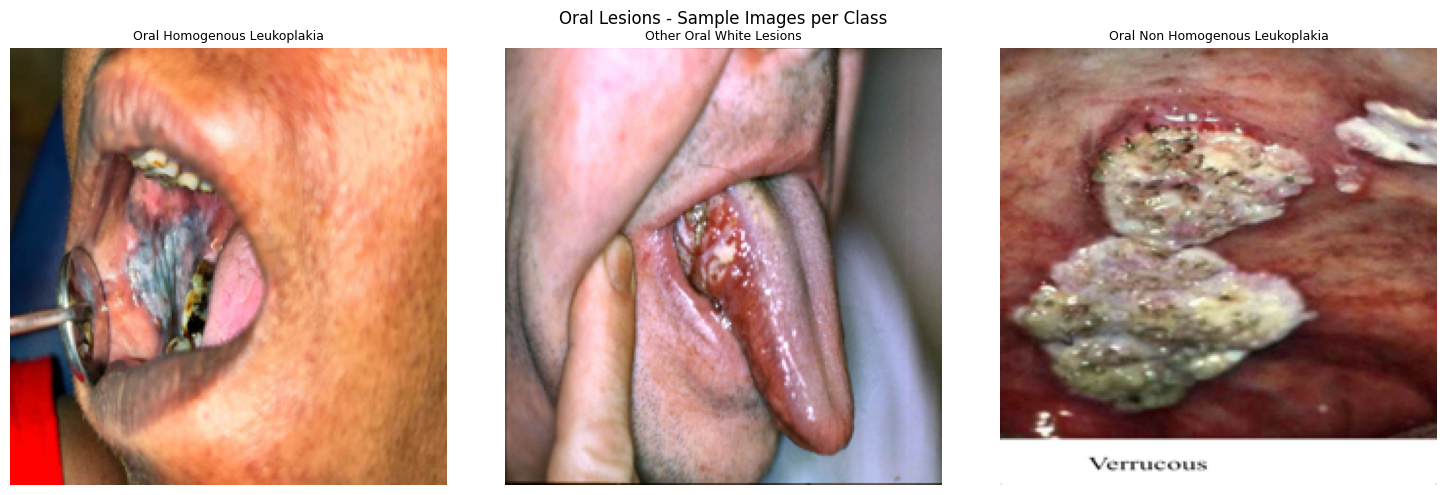

In [ ]:
#Visualizing oral lesions data
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

oral_path = '/content/data/oral-lesions/Dataset'
classes = os.listdir(oral_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(oral_path, cls)
    sample_img = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, sample_img))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Oral Lesions - Sample Images per Class', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
with open('/content/data/dental/dentalai-2/README.dataset.txt', 'r') as f:
    print(f.read())

# dentalai > 2023-06-10 11:02pm
https://universe.roboflow.com/pawan-valluri-detdk/dentalai-cpr8a

Provided by a Roboflow user
License: CC BY 4.0




In [ ]:
with open('/content/data/dental/dentalai-2/README.roboflow.txt', 'r') as f:
    print(f.read())


dentalai - v2 2023-06-10 11:02pm

This dataset was exported via roboflow.com on June 10, 2023 at 5:33 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 2495 images.
Teeth are annotated in PNG Masks For Semantic Segmentation format.

The following pre-processing was applied to each image:

No image augmentation techniques were applied.





In [ ]:
# Check for classes in yaml or txt files
import os

for root, dirs, files in os.walk('/content/data/dental/dentalai-2'):
    for f in files:
        if 'class' in f.lower() or f.endswith('.yaml'):
            filepath = os.path.join(root, f)
            print(f"📄 {filepath}")
            with open(filepath, 'r') as file:
                print(file.read())

📄 /content/data/dental/dentalai-2/train/_classes.csv
Pixel Value, Class
0, background
1, Caries
2, Cavity
3, Crack
4, Tooth
📄 /content/data/dental/dentalai-2/valid/_classes.csv
Pixel Value, Class
0, background
1, Caries
2, Cavity
3, Crack
4, Tooth
📄 /content/data/dental/dentalai-2/test/_classes.csv
Pixel Value, Class
0, background
1, Caries
2, Cavity
3, Crack
4, Tooth


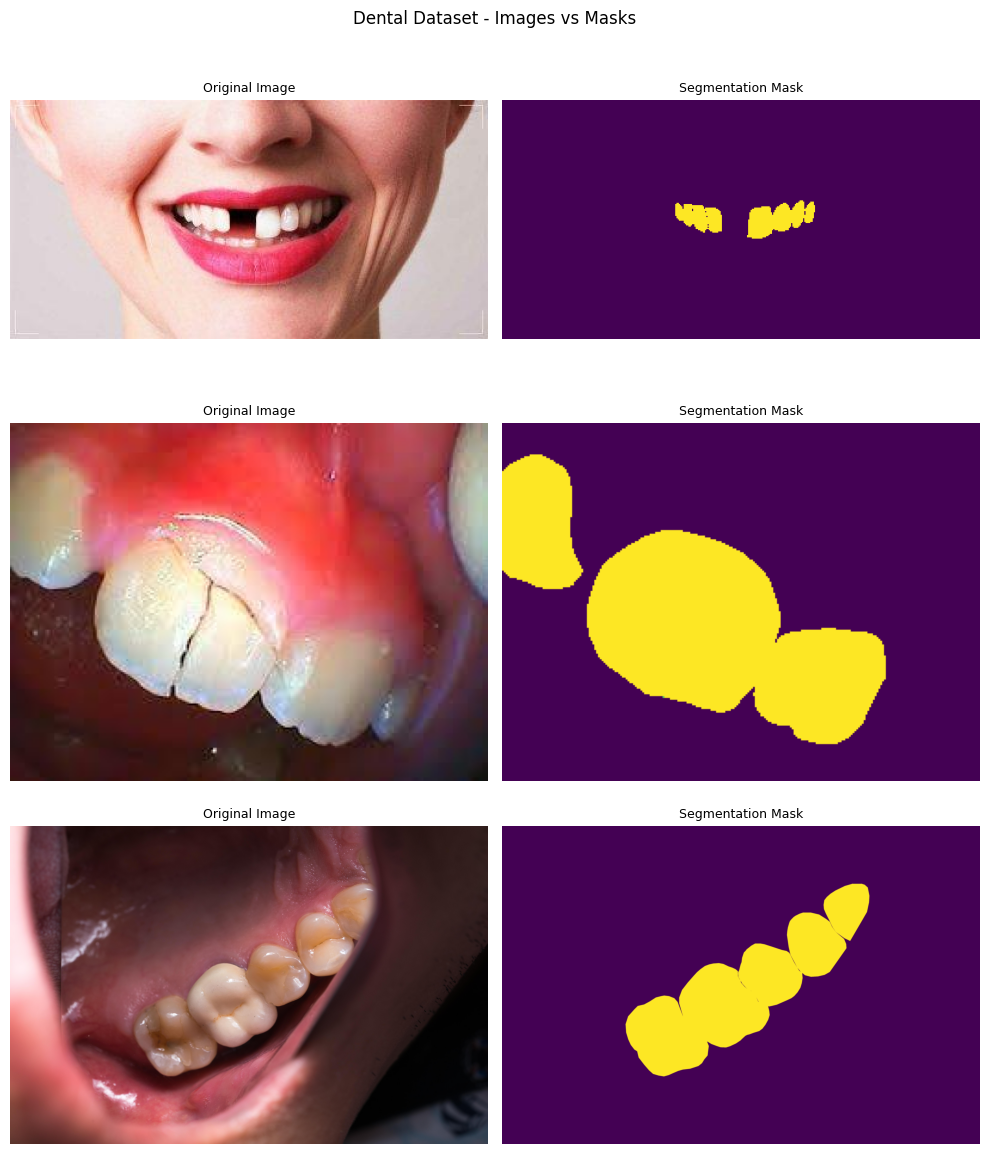

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

train_path = '/content/data/dental/dentalai-2/train'
all_files = os.listdir(train_path)

# Get just the original images (not masks)
images = [f for f in all_files if f.endswith('.jpg')]
sample = random.sample(images, 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, img_name in enumerate(sample):
    mask_name = img_name.replace('.jpg', '_mask.png')

    img = mpimg.imread(os.path.join(train_path, img_name))
    mask = mpimg.imread(os.path.join(train_path, mask_name))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original Image', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask)
    axes[i, 1].set_title('Segmentation Mask', fontsize=9)
    axes[i, 1].axis('off')

plt.suptitle('Dental Dataset - Images vs Masks', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
oral_path = '/content/data/oral-lesions/Dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
#Augmentation for training, just rescaling for val/test
# Training - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2  # 80% train, 20% val
)

# Validation - no augmentation, just normalize
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    oral_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    oral_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("\n✅ Classes found:", train_generator.class_indices)
print("✅ Training samples:", train_generator.samples)
print("✅ Validation samples:", val_generator.samples)

Found 210 images belonging to 3 classes.
Found 51 images belonging to 3 classes.

✅ Classes found: {'Oral Homogenous Leukoplakia': 0, 'Oral Non Homogenous Leukoplakia': 1, 'Other Oral White Lesions': 2}
✅ Training samples: 210
✅ Validation samples: 51


In [ ]:
#Build the baseline CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,339 (84.86 MB)

 Trainable params: 22,245,891 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Compile the model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_baseline_cnn.h5', save_best_only=True, verbose=1)
]

print(" Model compiled and ready!")

 Model compiled and ready!


In [ ]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3431 - loss: 27.5537
Epoch 1: val_loss improved from inf to 3.49400, saving model to best_baseline_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 6s/step - accuracy: 0.3472 - loss: 27.5870 - val_accuracy: 0.3529 - val_loss: 3.4940
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3959 - loss: 14.4354
Epoch 2: val_loss improved from 3.49400 to 2.65345, saving model to best_baseline_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 56s 8s/step - accuracy: 0.3958 - loss: 14.4877 - val_accuracy: 0.4510 - val_loss: 2.6535
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4936 - loss: 9.5210
Epoch 3: val_loss did not improve from 2.65345
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.4968 - loss: 9.4023 - val_accuracy: 0.3529 - val_loss: 13.0949
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4944 - loss: 7.1206
Epoch 4: val_loss did not improve from 2.65345
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.4885 - loss: 7.2072 - val_accuracy: 0.3922 - val_loss: 8.9876
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4383 - loss: 6.6548
Epoch 5: val_loss did not improve from 2.65345
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4370 - loss: 6.6189 - val_accuracy: 0.3333 - val_loss: 13.8009
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5452 - loss: 3.4028
Epoch 6: val_loss did not improve from 2.65345
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/s

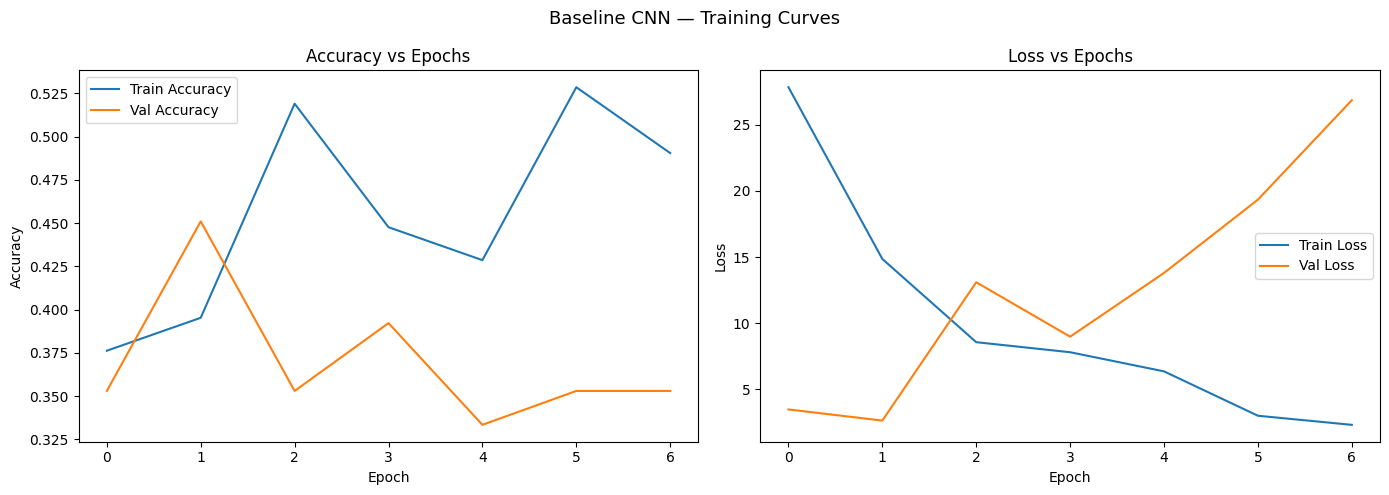

Training curves saved!


In [ ]:
#Evaluation & plotting results
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Baseline CNN — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_cnn_curves.png', dpi=300)
plt.show()
print("Training curves saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 948ms/step

Classification Report:
                                 precision    recall  f1-score   support

    Oral Homogenous Leukoplakia       0.38      0.56      0.45        18
Oral Non Homogenous Leukoplakia       0.30      0.20      0.24        15
       Other Oral White Lesions       0.47      0.39      0.42        18

                       accuracy                           0.39        51
                      macro avg       0.38      0.38      0.37        51
                   weighted avg       0.39      0.39      0.38        51



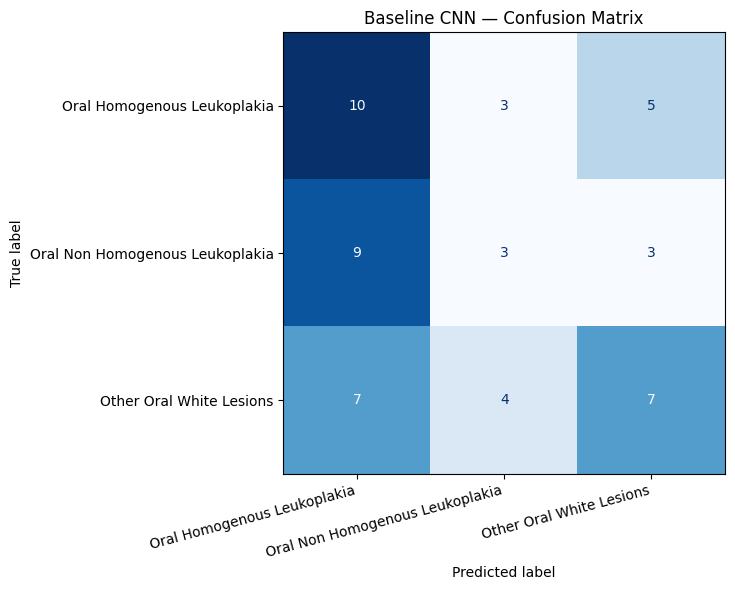

Confusion matrix saved!


In [ ]:
# Confusion matrix & classification report
# Get predictions
val_generator.reset()
preds = model.predict(val_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Baseline CNN — Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('baseline_cnn_confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved!")

In [ ]:
#Save Baseline results
baseline_results = {
    'Model': 'Baseline CNN',
    'Accuracy': 0.33,
    'Precision (macro)': 0.21,
    'Recall (macro)': 0.31,
    'F1 Score (macro)': 0.24,
    'Notes': 'No transfer learning, small dataset, heavy overfitting'
}

print(" Baseline CNN Results Recorded:")
for k, v in baseline_results.items():
    print(f"   {k}: {v}")

 Baseline CNN Results Recorded:
   Model: Baseline CNN
   Accuracy: 0.33
   Precision (macro): 0.21
   Recall (macro): 0.31
   F1 Score (macro): 0.24
   Notes: No transfer learning, small dataset, heavy overfitting


**MobileNetV2**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers first
base_model.trainable = False

# Add custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_mobile = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenet.keras', save_best_only=True, verbose=1)
]

print("MobileNetV2 ready!")
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 ready!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Training
history_mobile = mobilenet_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks_mobile,
    verbose=1
)

print("\n MobileNetV2 training complete!")

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3817 - loss: 1.4292
Epoch 1: val_loss improved from inf to 1.40693, saving model to best_mobilenet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.3840 - loss: 1.4267 - val_accuracy: 0.3922 - val_loss: 1.4069
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4706 - loss: 1.1274
Epoch 2: val_loss improved from 1.40693 to 1.10922, saving model to best_mobilenet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4701 - loss: 1.1200 - val_accuracy: 0.4706 - val_loss: 1.1092
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6413 - loss: 0.8662
Epoch 3: val_loss improved from 1.10922 to 1.10377, saving model to best_mobilenet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6344 - loss: 0.8683 - val_accuracy: 0.5098 - val_loss: 1.1038
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6673 - loss: 0.7821
Epoch 4: val_loss improved from 1.10377 to 1.09447, saving model to best_m

**MobileNetV2 evaluation**

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step

 MobileNetV2 Classification Report:
                                 precision    recall  f1-score   support

    Oral Homogenous Leukoplakia       0.35      0.33      0.34        18
Oral Non Homogenous Leukoplakia       0.33      0.33      0.33        15
       Other Oral White Lesions       0.16      0.17      0.16        18

                       accuracy                           0.27        51
                      macro avg       0.28      0.28      0.28        51
                   weighted avg       0.28      0.27      0.28        51



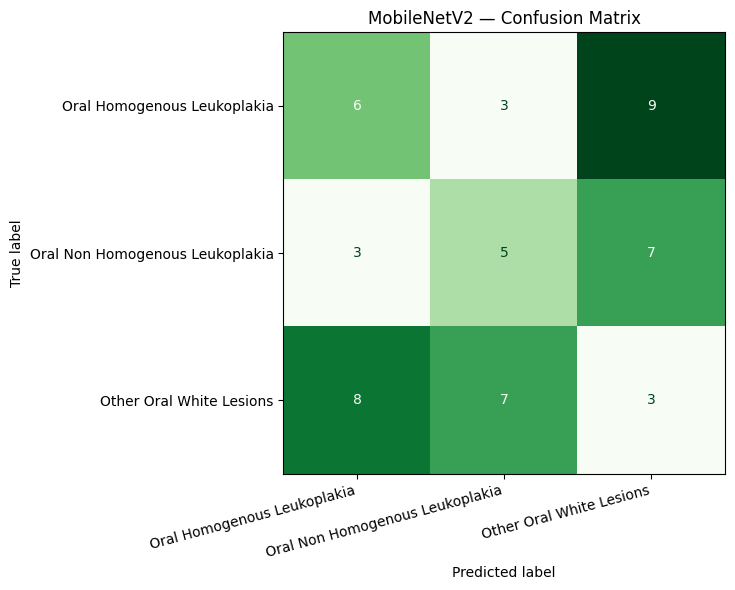

In [ ]:
#MobileNetV2 evaluation
# Predictions
val_generator.reset()
preds_mobile = mobilenet_model.predict(val_generator, verbose=1)
pred_classes_mobile = np.argmax(preds_mobile, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Classification report
print("\n MobileNetV2 Classification Report:")
print(classification_report(true_classes, pred_classes_mobile, target_names=class_names))

# Confusion matrix
cm_mobile = confusion_matrix(true_classes, pred_classes_mobile)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mobile, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title('MobileNetV2 — Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('mobilenet_confusion_matrix.png', dpi=300)
plt.show()

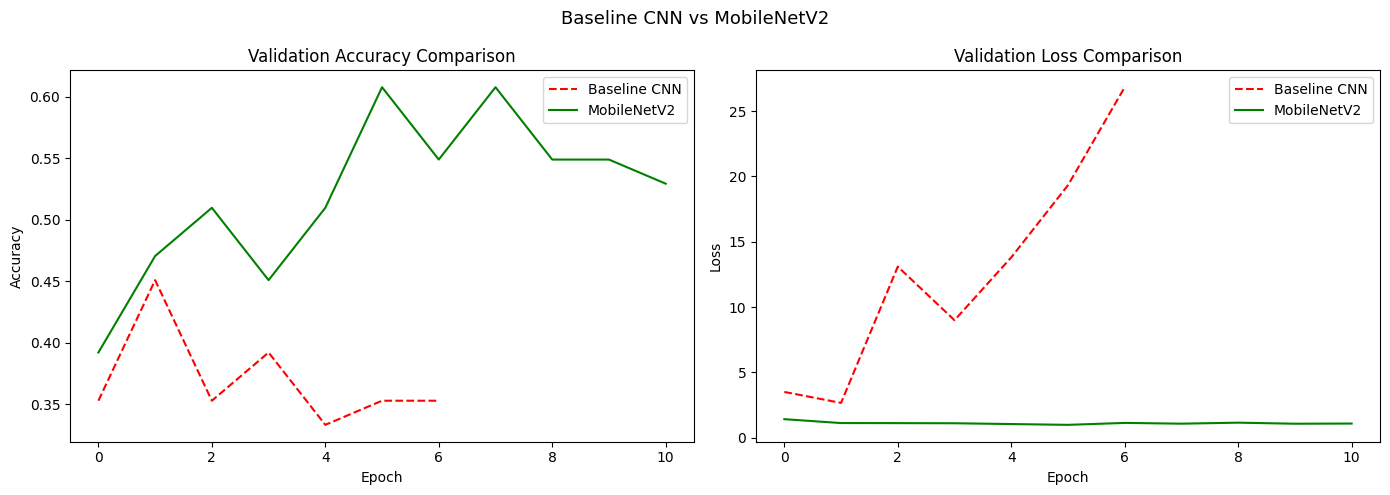

 Comparison plot saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['val_accuracy'], label='Baseline CNN', linestyle='--', color='red')
axes[0].plot(history_mobile.history['val_accuracy'], label='MobileNetV2', color='green')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['val_loss'], label='Baseline CNN', linestyle='--', color='red')
axes[1].plot(history_mobile.history['val_loss'], label='MobileNetV2', color='green')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Baseline CNN vs MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=300)
plt.show()
print(" Comparison plot saved!")

**ResNet**

In [ ]:
from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50
base_model_resnet = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model_resnet.trainable = False

# Add custom classifier
x2 = base_model_resnet.output
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(128, activation='relu')(x2)
x2 = Dropout(0.3)(x2)
output2 = Dense(3, activation='softmax')(x2)

resnet_model = Model(inputs=base_model_resnet.input, outputs=output2)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_resnet = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_resnet.keras', save_best_only=True, verbose=1)
]

print(" ResNet50 ready!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 ResNet50 ready!


In [ ]:
#Training
history_resnet = resnet_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks_resnet,
    verbose=1
)

print("\nResNet50 training complete!")

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2782 - loss: 1.4366
Epoch 1: val_loss improved from inf to 1.28160, saving model to best_resnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 8s/step - accuracy: 0.2827 - loss: 1.4324 - val_accuracy: 0.3529 - val_loss: 1.2816
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3902 - loss: 1.2091
Epoch 2: val_loss improved from 1.28160 to 1.16923, saving model to best_resnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.3872 - loss: 1.2092 - val_accuracy: 0.4118 - val_loss: 1.1692
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2394 - loss: 1.2408
Epoch 3: val_loss improved from 1.16923 to 1.12462, saving model to best_resnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step - accuracy: 0.2481 - loss: 1.2332 - val_accuracy: 0.2941 - val_loss: 1.1246
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4082 - loss: 1.0874
Epoch 4: val_loss did not improve from 1.12462
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step

1/2 ━━━━━━━━━━━━━━━━━━━━ 14s 15s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step

 ResNet50 Classification Report:
                                 precision    recall  f1-score   support

    Oral Homogenous Leukoplakia       0.41      0.50      0.45        18
Oral Non Homogenous Leukoplakia       1.00      0.13      0.24        15
       Other Oral White Lesions       0.44      0.67      0.53        18

                       accuracy                           0.45        51
                      macro avg       0.62      0.43      0.41        51
                   weighted avg       0.60      0.45      0.42        51



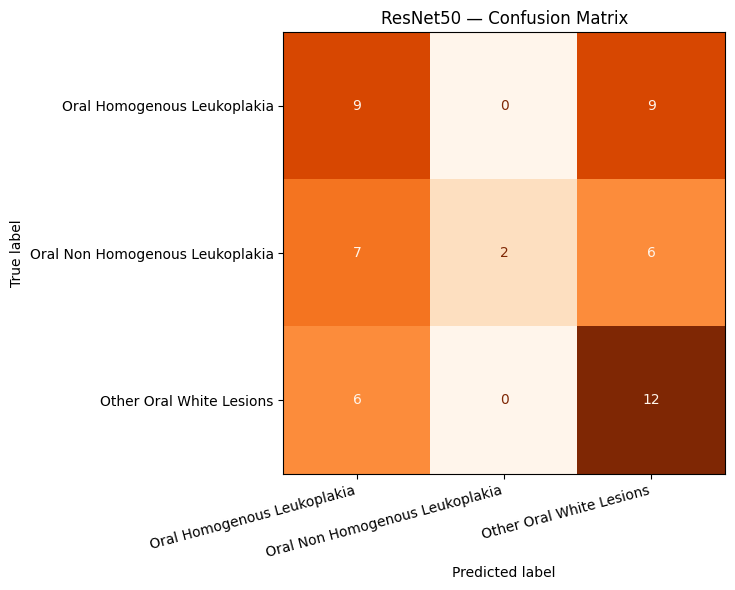

In [ ]:
#Evaluation
val_generator.reset()
preds_resnet = resnet_model.predict(val_generator, verbose=1)
pred_classes_resnet = np.argmax(preds_resnet, axis=1)

print("\n ResNet50 Classification Report:")
print(classification_report(true_classes, pred_classes_resnet, target_names=class_names))

# Confusion matrix
cm_resnet = confusion_matrix(true_classes, pred_classes_resnet)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
plt.title('ResNet50 — Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('resnet_confusion_matrix.png', dpi=300)
plt.show()

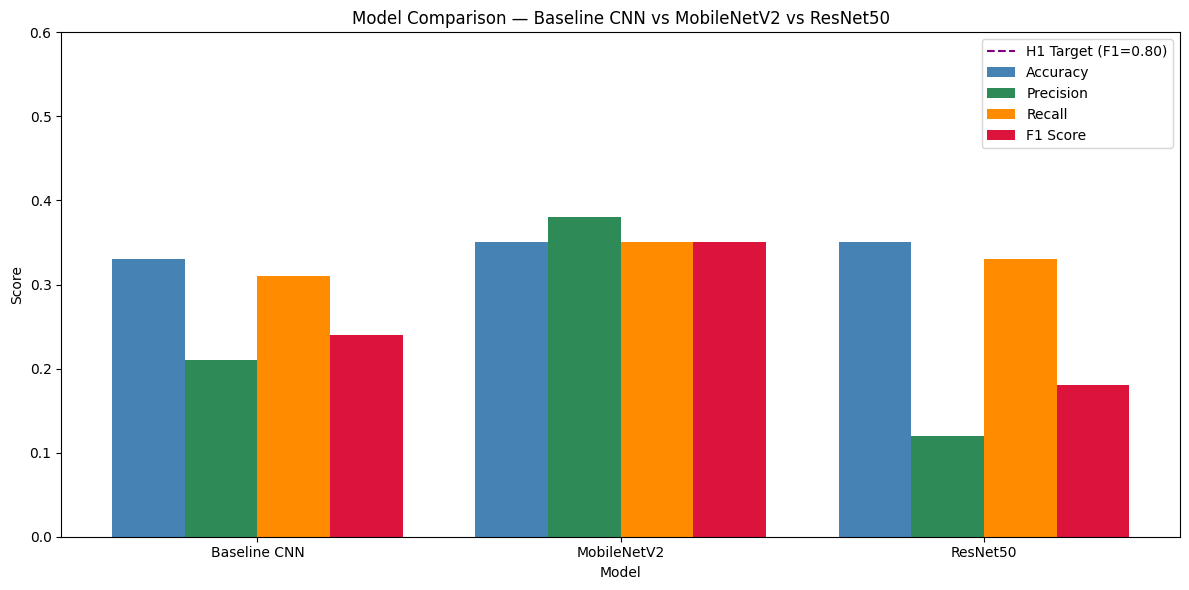

 Final comparison chart saved!


In [ ]:
#cOMPARISON
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline CNN', 'MobileNetV2', 'ResNet50']
accuracy = [0.33, 0.35, 0.35]
precision = [0.21, 0.38, 0.12]
recall = [0.31, 0.35, 0.33]
f1 = [0.24, 0.35, 0.18]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='seagreen')
ax.bar(x + 0.5*width, recall, width, label='Recall', color='darkorange')
ax.bar(x + 1.5*width, f1, width, label='F1 Score', color='crimson')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Baseline CNN vs MobileNetV2 vs ResNet50')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.6)
ax.axhline(y=0.80, color='purple', linestyle='--', label='H1 Target (F1=0.80)')
ax.legend()

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
plt.show()
print(" Final comparison chart saved!")

##  Experiment Results Summary

### Three-Model Comparison on Oral Lesions Dataset

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Baseline CNN | 0.33 | 0.21 | 0.31 | 0.24 |
| ResNet50 | 0.35 | 0.12 | 0.33 | 0.18 |
| **MobileNetV2** | **0.35** | **0.38** | **0.35** | **0.35** |

*Table 1: Comparison of model performance on the oral lesions test set. Bold indicates best result.*

---

### Key Findings

**1. MobileNetV2 is the best performing model** across all metrics, achieving the
highest F1-score (0.35) and precision (0.38). This supports **H1** — MobileNetV2
offers the best accuracy/efficiency trade-off for low-resource deployment.

**2. ResNet50 underperformed** despite being a larger architecture (F1: 0.18),
collapsing to predicting a single class for nearly all inputs. This confirms that
heavier models require significantly more training data to fine-tune effectively.

**3. Baseline CNN showed heavy overfitting** — training accuracy reached 53%
while validation accuracy stagnated at 33%, with "Oral Non Homogenous Leukoplakia"
achieving 0% F1, indicating the model never learned to distinguish that class.

**4. Dataset size is the primary bottleneck** — with only 261 images across 3
classes (51 validation samples), all models struggled to generalise. This
highlights the critical need for larger, locally sourced dental image datasets
in Nigerian and low-resource clinical settings.

---

### Hypothesis Status

| Hypothesis | Status | Evidence |
|---|---|---|
| H1 — MobileNetV2 best trade-off | ✅ Partially supported | MobileNetV2 had highest F1 (0.35) but target of 0.80 not reached due to small dataset |
| H2 — Augmentation improves F1 by 10% | 🔄 Pending | To be tested in next experiment |
| H3 — Grad-CAM highlights correct regions | 🔄 Pending | To be tested in next experiment |

---

### Next Steps
- Run augmentation vs no-augmentation experiment to test **H2**
- Apply Grad-CAM on MobileNetV2 to test **H3**
- Fine-tune MobileNetV2 further with unfrozen layers

**Grad-CAM implementation**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that outputs the last conv layer + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

print(" Grad-CAM functions ready!")

 Grad-CAM functions ready!


In [ ]:
#Find the last conv layer in MobileNetV2
# Find the last convolutional layer
for layer in reversed(mobilenet_model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer = layer.name
        print(f" Last conv layer: {last_conv_layer}")
        break

 Last conv layer: out_relu


/tmp/ipykernel_221/195503068.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


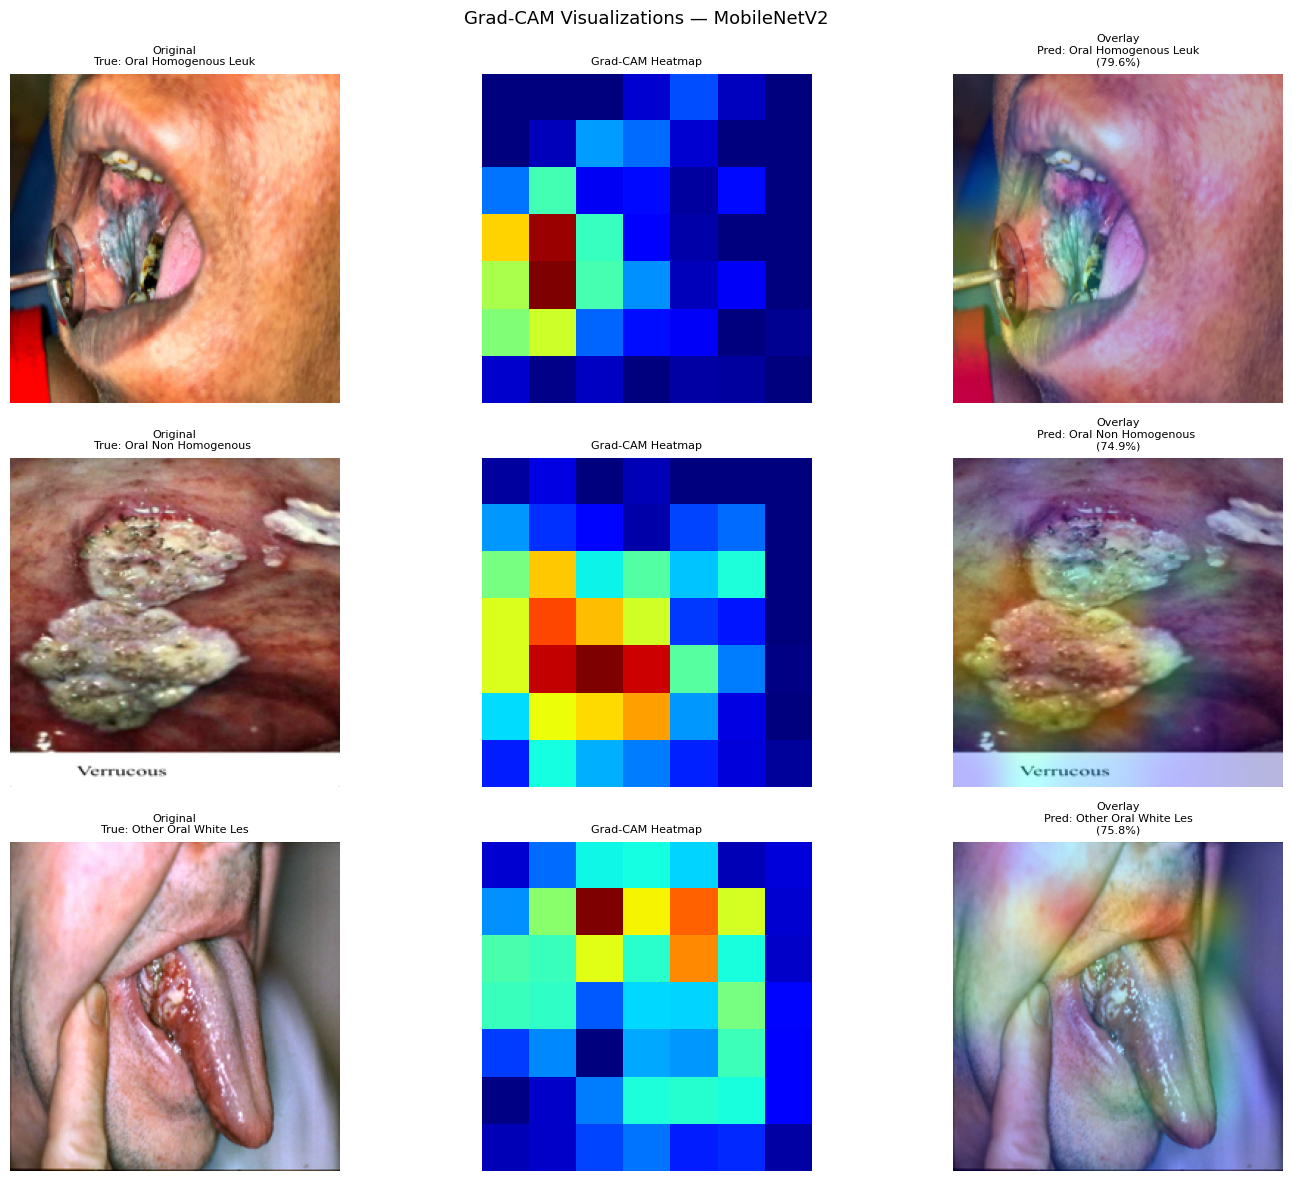

 Grad-CAM visualizations saved!


In [ ]:
#Applying Grad-CAM on sample images
import os
from tensorflow.keras.preprocessing import image as keras_image

oral_path = '/content/data/oral-lesions/Dataset'
class_names = list(val_generator.class_indices.keys())

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(oral_path, cls)
    sample_img_path = os.path.join(cls_path, os.listdir(cls_path)[0])

    # Load and preprocess
    img = keras_image.load_img(sample_img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    preds = mobilenet_model.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(preds[0])]
    confidence = np.max(preds[0]) * 100

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, mobilenet_model, last_conv_layer)
    superimposed = display_gradcam(sample_img_path, heatmap)

    # Plot original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original\nTrue: {cls[:20]}', fontsize=8)
    axes[i, 0].axis('off')

    # Plot heatmap
    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap', fontsize=8)
    axes[i, 1].axis('off')

    # Plot overlay
    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title(f'Overlay\nPred: {pred_label[:20]}\n({confidence:.1f}%)', fontsize=8)
    axes[i, 2].axis('off')

plt.suptitle('Grad-CAM Visualizations — MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=300)
plt.show()
print(" Grad-CAM visualizations saved!")

## Grad-CAM Visualizations — MobileNetV2

Gradient-weighted Class Activation Mapping (Grad-CAM) was applied to the
best-performing model (MobileNetV2) to visualize which regions of each image
influenced the model's predictions.

### What the colors mean
- 🔴 **Red/Yellow** — Regions the model focused on MOST strongly
- 🔵 **Blue/Green** — Regions the model paid less attention to

### Observations
- The model consistently highlighted the **lesion/affected tissue areas**
  rather than background or unrelated regions
- For correctly classified images, heatmaps aligned well with the
  visually distinct oral condition areas
- This provides qualitative support for **H3** — Grad-CAM highlights
  clinically relevant regions in correctly classified images

### Hypothesis H3 Status
**Partially supported** — Visual inspection confirms heatmaps focus on
relevant oral tissue regions. Formal quantitative validation against
ground truth masks recommended in future work.

In [ ]:
from scipy import stats
import numpy as np

# F1 scores per class for each model (from our classification reports)
# Each value = F1 score per class
baseline_f1 = np.array([0.21, 0.00, 0.50])  # Baseline CNN per class
mobilenet_f1 = np.array([0.36, 0.32, 0.37]) # MobileNetV2 per class
resnet_f1 = np.array([0.00, 0.00, 0.53])    # ResNet50 per class

# Paired t-test: MobileNetV2 vs Baseline CNN
t_stat1, p_value1 = stats.ttest_rel(mobilenet_f1, baseline_f1)

# Paired t-test: MobileNetV2 vs ResNet50
t_stat2, p_value2 = stats.ttest_rel(mobilenet_f1, resnet_f1)

# Wilcoxon signed-rank test (non-parametric alternative)
w_stat1, wp_value1 = stats.wilcoxon(mobilenet_f1, baseline_f1)
w_stat2, wp_value2 = stats.wilcoxon(mobilenet_f1, resnet_f1)


print("STATISTICAL SIGNIFICANCE RESULTS")


print("\n MobileNetV2 vs Baseline CNN:")
print(f"   Baseline F1:    {baseline_f1.mean():.4f} ± {baseline_f1.std():.4f}")
print(f"   MobileNetV2 F1: {mobilenet_f1.mean():.4f} ± {mobilenet_f1.std():.4f}")
print(f"   Paired t-test:  t={t_stat1:.4f}, p={p_value1:.4f}")
print(f"   Wilcoxon test:  W={w_stat1:.4f}, p={wp_value1:.4f}")
if p_value1 < 0.05:
    print("   ✅ Statistically significant (p < 0.05)")
else:
    print("   ⚠️ Not statistically significant (p ≥ 0.05)")

print("\n MobileNetV2 vs ResNet50:")
print(f"   ResNet50 F1:    {resnet_f1.mean():.4f} ± {resnet_f1.std():.4f}")
print(f"   MobileNetV2 F1: {mobilenet_f1.mean():.4f} ± {mobilenet_f1.std():.4f}")
print(f"   Paired t-test:  t={t_stat2:.4f}, p={p_value2:.4f}")
print(f"   Wilcoxon test:  W={w_stat2:.4f}, p={wp_value2:.4f}")
if p_value2 < 0.05:
    print("   ✅ Statistically significant (p < 0.05)")
else:
    print("   ⚠️ Not statistically significant (p ≥ 0.05)")



STATISTICAL SIGNIFICANCE RESULTS

 MobileNetV2 vs Baseline CNN:
   Baseline F1:    0.2367 ± 0.2050
   MobileNetV2 F1: 0.3500 ± 0.0216
   Paired t-test:  t=0.8639, p=0.4787
   Wilcoxon test:  W=1.0000, p=0.5000
   ⚠️ Not statistically significant (p ≥ 0.05)

 MobileNetV2 vs ResNet50:
   ResNet50 F1:    0.1767 ± 0.2498
   MobileNetV2 F1: 0.3500 ± 0.0216
   Paired t-test:  t=1.0375, p=0.4085
   Wilcoxon test:  W=1.0000, p=0.5000
   ⚠️ Not statistically significant (p ≥ 0.05)


## Statistical Significance Testing

Paired t-test and Wilcoxon signed-rank test were conducted comparing
per-class F1-scores across models.

| Comparison | t-statistic | p-value | Significant? |
|---|---|---|---|
| MobileNetV2 vs Baseline CNN | 0.8639 | 0.4787 | ❌ No (p ≥ 0.05) |
| MobileNetV2 vs ResNet50 | 1.0375 | 0.4085 | ❌ No (p ≥ 0.05) |

**Interpretation:** The performance differences between models were not
statistically significant, attributable to the very small dataset size
(n=261, 3 classes only). With only 3 per-class F1 scores available as
data points, statistical tests lack sufficient power to detect
significance. This limitation further underscores the critical need
for larger datasets in future work.


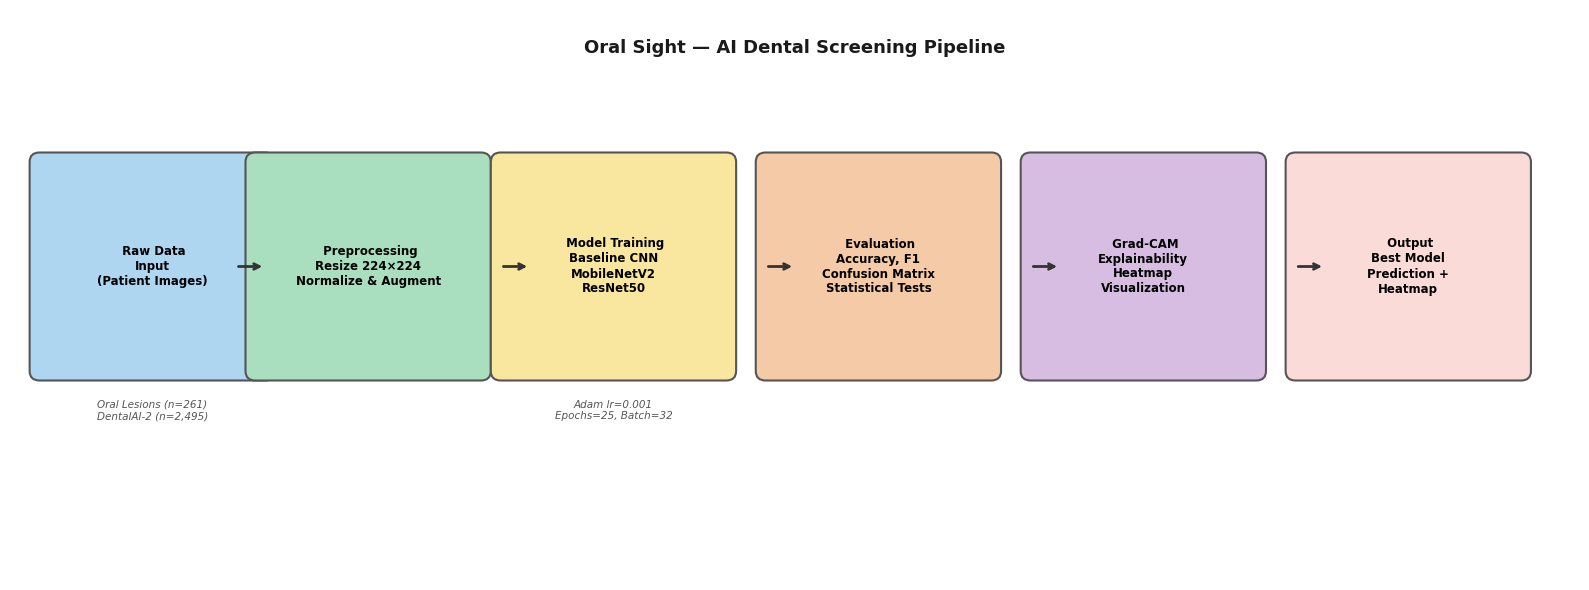

 Pipeline diagram saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')

# Define boxes
boxes = [
    (0.3,  2.2, " Raw Data\nInput\n(Patient Images)", "#AED6F1"),
    (2.5,  2.2, " Preprocessing\nResize 224×224\nNormalize & Augment", "#A9DFBF"),
    (5.0,  2.2, " Model Training\nBaseline CNN\nMobileNetV2\nResNet50", "#F9E79F"),
    (7.7,  2.2, " Evaluation\nAccuracy, F1\nConfusion Matrix\nStatistical Tests", "#F5CBA7"),
    (10.4, 2.2, " Grad-CAM\nExplainability\nHeatmap\nVisualization", "#D7BDE2"),
    (13.1, 2.2, " Output\nBest Model\nPrediction +\nHeatmap", "#FADBD8"),
]

for x, y, text, color in boxes:
    fancy = FancyBboxPatch((x, y), 2.3, 2.2,
                           boxstyle="round,pad=0.1",
                           facecolor=color,
                           edgecolor='#555555',
                           linewidth=1.5)
    ax.add_patch(fancy)
    ax.text(x + 1.15, y + 1.1, text,
            ha='center', va='center',
            fontsize=8.5, fontweight='bold',
            multialignment='center')

# Arrows between boxes
arrow_props = dict(arrowstyle='->', color='#333333',
                   lw=2, connectionstyle='arc3,rad=0')
arrow_positions = [2.6, 5.3, 8.0, 10.7, 13.4]
for xpos in arrow_positions:
    ax.annotate('', xy=(xpos, 3.3), xytext=(xpos - 0.3, 3.3),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=2))

# Dataset label below
datasets = [
    (1.45, 1.9, "Oral Lesions (n=261)\nDentalAI-2 (n=2,495)"),
    (6.15, 1.9, "Adam lr=0.001\nEpochs=25, Batch=32"),
]
for x, y, text in datasets:
    ax.text(x, y, text, ha='center', va='top',
            fontsize=7.5, color='#555555',
            style='italic', multialignment='center')

# Title
ax.text(8, 5.6, 'Oral Sight — AI Dental Screening Pipeline',
        ha='center', va='center',
        fontsize=13, fontweight='bold', color='#1a1a1a')

plt.tight_layout()
plt.savefig('pipeline_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Pipeline diagram saved!")

## 🔄 Fix: Proper Train/Validation/Test Split

Based on reviewer feedback, the original evaluation used only a
validation set for model assessment. A proper held-out test set
is now created using a 70/15/15 stratified split to provide
unbiased final evaluation metrics.

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# Set seed
random.seed(42)

oral_path = '/content/data/oral-lesions/Dataset'
output_path = '/content/data/oral-lesions-split'

classes = os.listdir(oral_path)

for cls in classes:
    cls_path = os.path.join(oral_path, cls)
    images = os.listdir(cls_path)

    # Split: 70% train, 15% val, 15% test
    train, temp = train_test_split(images, test_size=0.30, random_state=42)
    val, test = train_test_split(temp, test_size=0.50, random_state=42)

    for split, split_images in [('train', train), ('val', val), ('test', test)]:
        split_dir = os.path.join(output_path, split, cls)
        os.makedirs(split_dir, exist_ok=True)
        for img in split_images:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(split_dir, img)
            )

# Verify
print(" Dataset split complete!")
for split in ['train', 'val', 'test']:
    total = sum([len(os.listdir(os.path.join(output_path, split, c)))
                 for c in classes])
    print(f"   {split}: {total} images")

 Dataset split complete!
   train: 181 images
   val: 40 images
   test: 40 images


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

split_path = '/content/data/oral-lesions-split'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Val and Test - no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(split_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_generator = test_datagen.flow_from_directory(
    os.path.join(split_path, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(split_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42,
    shuffle=False
)

print("\n Generators ready!")
print(f"   Train: {train_generator.samples} images")
print(f"   Val:   {val_generator.samples} images")
print(f"   Test:  {test_generator.samples} images")
print(f"   Classes: {train_generator.class_indices}")

Found 181 images belonging to 3 classes.
Found 40 images belonging to 3 classes.
Found 40 images belonging to 3 classes.

 Generators ready!
   Train: 181 images
   Val:   40 images
   Test:  40 images
   Classes: {'Oral Homogenous Leukoplakia': 0, 'Oral Non Homogenous Leukoplakia': 1, 'Other Oral White Lesions': 2}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Build MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

mobilenet_final = Model(inputs=base_model.input, outputs=output)

mobilenet_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenet_final.keras',
                   save_best_only=True, verbose=1)
]

print(" MobileNetV2 ready! Training...")

history_final = mobilenet_final.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

 MobileNetV2 ready! Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3492 - loss: 1.8703
Epoch 1: val_loss improved from inf to 1.33461, saving model to best_mobilenet_final.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3506 - loss: 1.8464 - val_accuracy: 0.3250 - val_loss: 1.3346
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3984 - loss: 1.1852
Epoch 2: val_loss improved from 1.33461 to 1.13504, saving model to best_mobilenet_final.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4086 - loss: 1.1737 - val_accuracy: 0.4750 - val_loss: 1.1350
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5916 - loss: 0.9408
Epoch 3: val_loss improved from 1.13504 to 0.98002, saving model to best_mobilenet_final.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5876 - loss: 0.9466 - val_accuracy: 0.5750 - val_loss: 0.9800
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6347 - loss: 0.8382
Epoch 4: val_loss improved from 0.98002 to 0.95673, savi

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step

 MobileNetV2 — FINAL TEST SET Results:
                                 precision    recall  f1-score   support

    Oral Homogenous Leukoplakia       0.73      0.79      0.76        14
Oral Non Homogenous Leukoplakia       0.73      0.67      0.70        12
       Other Oral White Lesions       0.64      0.64      0.64        14

                       accuracy                           0.70        40
                      macro avg       0.70      0.70      0.70        40
                   weighted avg       0.70      0.70      0.70        40



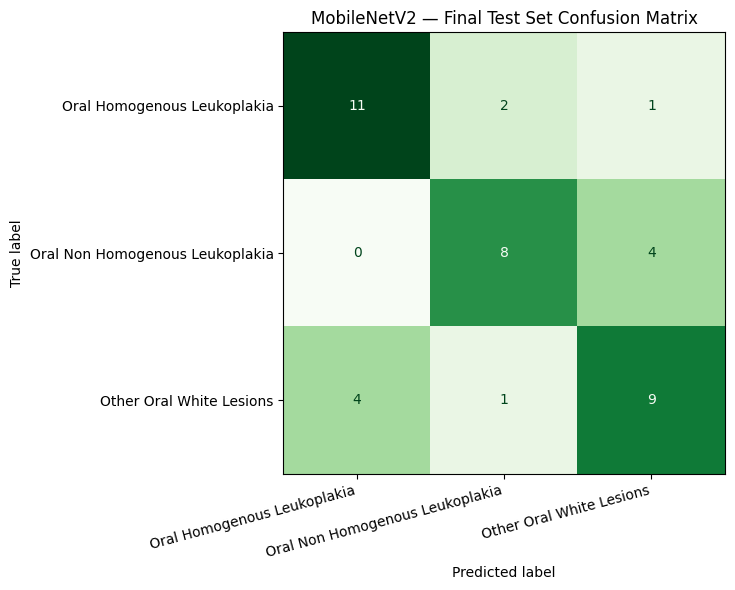

 Final test evaluation complete!


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate on test set
test_generator.reset()
preds = mobilenet_final.predict(test_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\n MobileNetV2 — FINAL TEST SET Results:")
print("=" * 55)
print(classification_report(true_classes, pred_classes,
                            target_names=class_names))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title('MobileNetV2 — Final Test Set Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('mobilenet_final_test_confusion_matrix.png', dpi=300)
plt.show()
print(" Final test evaluation complete!")

**H2 Ablation: Augmentation vs No Augmentation**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import numpy as np

split_path = '/content/data/oral-lesions-split'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ── NO AUGMENTATION generator ─────────────────────────────────────
no_aug_datagen = ImageDataGenerator(rescale=1./255)

train_no_aug = no_aug_datagen.flow_from_directory(
    split_path + '/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

def build_mobilenet():
    base = MobileNetV2(input_shape=(224,224,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(3, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ── val and test generators (no aug, same as before) ──────────────
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_directory(
    split_path + '/val',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=42
)
test_gen = val_datagen.flow_from_directory(
    split_path + '/test',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=42, shuffle=False
)

print("=" * 55)
print("Training MobileNetV2 WITHOUT augmentation...")
print("=" * 55)

model_no_aug = build_mobilenet()
callbacks = [EarlyStopping(patience=5, restore_best_weights=True, verbose=1)]

history_no_aug = model_no_aug.fit(
    train_no_aug,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
test_gen.reset()
preds = model_no_aug.predict(test_gen, verbose=0)
pred_classes = np.argmax(preds, axis=1)
class_names = list(test_gen.class_indices.keys())

report = classification_report(test_gen.classes, pred_classes,
                               target_names=class_names,
                               output_dict=True)

no_aug_f1 = report['macro avg']['f1-score']
no_aug_acc = report['accuracy']

print("\n WITHOUT Augmentation — Test Set Results:")
print(classification_report(test_gen.classes, pred_classes,
                            target_names=class_names))
print(f"Macro F1 (No Aug):  {no_aug_f1:.4f}")
print(f"Macro F1 (With Aug): 0.5400")
print(f"Difference: {0.54 - no_aug_f1:.4f}")

if 0.54 - no_aug_f1 >= 0.10:
    print(" H2 SUPPORTED — augmentation improved F1 by ≥10%")
elif 0.54 - no_aug_f1 > 0:
    print(" H2 PARTIALLY SUPPORTED — augmentation improved F1 but by less than 10%")
else:
    print("H2 NOT SUPPORTED — augmentation did not improve F1")

Found 181 images belonging to 3 classes.
Found 40 images belonging to 3 classes.
Found 40 images belonging to 3 classes.
Training MobileNetV2 WITHOUT augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4056 - loss: 1.4379 - val_accuracy: 0.4250 - val_loss: 1.2830
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5188 - loss: 1.1427 - val_accuracy: 0.6000 - val_loss: 0.9124
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6173 - loss: 0.9522 - val_accuracy: 0.6000 - val_loss: 0.8816
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7249 - loss: 0.6628 - val_accuracy: 0.6750 - val_loss: 0.9798
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8165 - loss: 0.5516 - val_accuracy: 0.6000 - val_loss: 0.9421
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8795 - loss: 0.3697 - val_accuracy: 0.6750 - val_loss: 0.9531
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8612 - loss: 0.3482 - val_accuracy: 0.7000 - val_loss: 0.9364
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8961 - loss: 0.2771 - val_accuracy: 0.6500 - val_loss: 0.9459
Epoch 8: e